# Week 10


## Question 1
Create a `CashRegister` class with the following functionality.
* create an object by passing in the initial cash that the register starts with in terms of the number of loonies, toonies, fives, tens, and twenties
* print the contents of the register
* calculate and return the value of the contents of the register
* add some cash (specify the number of loonies, toonies, etc.)
* remove some cash: enter the dollar amount to remove, calculate the number of loonies, toonies, etc. that you need to remove, and decrement these values from the register.

Hint: remember week3?

In [9]:
class CashRegister:
    def __init__(self, loonies: int = 0, toonies: int = 0, fives: int = 0, tens: int = 0, twenties: int = 0) -> None:
        self.loonies = loonies
        self.toonies = toonies
        self.fives = fives
        self.tens = tens
        self.twenties = twenties

    def __str__(self) -> str:
        return (f'loonies: {self.loonies}\ntoonies: {self.toonies}\nfives: {self.fives}\ntens: {self.tens}\ntwenties: {self.twenties}')
    
    def calculate_value(self) -> int:
        '''() -> int
        
        Returns the value inside the register'''
        return self.loonies + 2 * self.toonies + 5 * self.fives + 10 * self.tens + 20 * self.twenties
    
    

In [10]:
print(CashRegister(1,2,3,4,5))

cash = CashRegister(2,3,4,5,6)
CashRegister.calculate_value(cash)

loonies: 1
toonies: 2
fives: 3
tens: 4
twenties: 5


198

## Question 2
How did you implement the **storage of the data** inside `CashRegister` in Q1?  
Reimplement the class (call it `CashRegister2`) with a different way of storing the data inside (e.g. use dictionary vs individual attributes). Note that all the code that you wrote to use `CashRegister` from outside the class should not have to change. Compare the implementation of `CashRegister` with `CashRegister2`, think about the pros and cons of each implementation.

## Question 3
Extend the `CashRegister` class from Q1 and Q2 by adding a method called `make_purchase` with the parameters: the cost of the item purchased and the number of 20s, 10s, 5s, toonies, and loonies given by the purchaser. The method should:
* add the cash to itself
* calculate the change that is due
* calculate what combination of 20s, 10s, 5s, toonies, and loonies will be used to make up the change
* remove the cash from itself

Some of this functionality should re-use methods you already wrote. You may want to revisit and change the code you already wrote to make it more convenient to implement `make_purchase`. (This is called "refactoring" and it happens all the time. That is, due to new functionality, you realize you can redesign the code you already have to make the new functionality easier to implement without breaking the old functionality).

## Question 4

You are given a one-dimensional representation of a world with landmarks represented by patterns of black and white (see diagram below). You can assume that you
have a map of the world in the form of a list where each entry is "black" or "white". For example, for the picture above the map is:

    ['black','white','white','black','white','black','black','black','white']
    
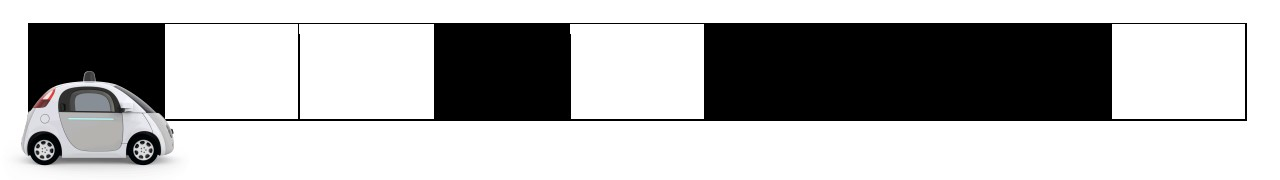

A robot (or autonomous vehicle) starts out at some location indicated by the index into the map (e.g., if the location was 2 it would correspond to the third entry in the list). The robot, however, **doesn’t know the index that it is at**. The robot can do three main things:
* move one location to the right
* sense the color of its current location
* localize: determine the locations it could be in based on all the sensor readings it has taken
You need to write code for all of this but mostly for the robot to figure out where it is.
To make things simpler, assume:
* the user chooses the starting location of the robot (but doesn’t tell the robot)
* the robot prompts the user for the sensor readings. That is, the user has perfect knowledge: he/she knows where the robot is and can always provide an accurate sensor reading.
* If the robot moves right from the last location, it wraps around to the first location (i.e. the world is not flat, it is circular)

Write your solutions as an object-oriented program.  

For example, let's say the robot is at index 0 in the above map.

Map: 

    ['black','white','white','black','white','black','black' ,'black','white']

Robot position: 0

The robot is at location 0 (but doesn’t know it). Here is how you might go about solving the problem:
*  Use your sensor (i.e., ask the user for the color). It measures 'black' and so you know that you must be at one of the black locations {0, 3, 5, 6, 7}.
* Move (and so the robot is really at 1 but doesn’t know it) and then user your sensor. It measures ‘white’. What are the possible locations that the robot can be at? There are only 3 consecutive locations that have the pattern `['black','white']` so the robot must now be at one of {1, 4, 8}. Remember that the robot has moved!
* Keep going until the robot can figure out where it is. Remember that since the robot is moving, you want to figure out where it is now – which is not the same place it started.

## Question 5
One method of estimating $\pi$ is to use Monte Carlo simulation as follows.

Place a circle with radius, $r$, inside a square with sides of length $2r$. The area of the circle is $\pi r^2$ and the area of the square is $(2r)^2$. Therefore, the ratio of the area of the circle to that of the square is $\frac{\pi}{4}$. If you randomly choose $n$ points inside the square, approximately $\frac{n\cdot \pi}{4}$ of them will be inside the circle. So by counting the number of points inside the square but outside the circle compared to the number of points inside both the square and the circle, you can estimate $\pi$: let $m$ be the number of points inside the circle. $\pi$ can then be estimated as $\frac{4\cdot m}{n}$.

Write a program that estimates $\pi$ by randomly picking points inside the square and testing if they are inside the circle.

To do this, you should create an object-oriented program with three classes:
* `Point`
* `Square` (implemented using `Point`)
* `Circle` (also implemented using `Point` – how?)


To implement the estimate, `Square` should have a method called `generate_random_point` that returns a random `Point` inside the `Square`. `Circle` should have a method called `check_inside` which takes a Point and returns `True`/`False` depending on whether the point is inside the `Circle` or not. 

In [19]:
import random

class Point:
    '''Represents a point by x- and y-coordinates.'''
    def __init__(self, x: int = 0, y: int = 0) -> None:
        self.x = x
        self.y = y

class Square:
    '''Represents a square by its geometric centre point and half side length.'''
    def __init__(self, half_side_length: int, x: int = 0, y: int = 0) -> None:
        '''(int, int, int) -> None'''
        self.centre = Point(x, y)
        self.half_side = half_side_length

    def generate_random_point(self) -> Point:
        '''() -> Point
        
        Generate a random point inside the square'''
        rand_x = random.randint(self.centre.x - self.half_side, self.centre.x + self.half_side)
        rand_y = random.randint(self.centre.y - self.half_side, self.centre.y + self.half_side)
        return Point(rand_x, rand_y)
    
class Circle:
    '''Represents a circle by its centre and radius.'''
    def __init__(self, radius: int, x: int = 0, y: int = 0) -> None:
        '''(int, int, int) -> None'''
        self.centre = Point(x, y)
        self.radius = radius

    def check_inside(self, point: Point) -> bool:
        '''(Point) -> bool 
        
        Checks if a Point object is inside a circle.'''
        radius_square = self.radius ** 2
        distance_to_centre_square = (point.x) ** 2 + (point.y) ** 2
        return distance_to_centre_square < radius_square

In [26]:
# say centre is all (0,0)
radius = 10000  # the larger the better
circle = Circle(radius)
square = Square(radius)

# initialize loop
total_iteration_time = 100000
number_inside = 0
for i in range(total_iteration_time):
    point = square.generate_random_point()
    if circle.check_inside(point):
        number_inside += 1

print(number_inside)
print(4 * number_inside / total_iteration_time)

78523
3.14092


## Question 6

**Note**: you will probably need to complete this question in your preferred Python IDE instead of Juputer Notebook, as `Turtle` will likely not work here at all.

You have seen `Turtle` in the lectures. Extend your code for Q5 by using a `Turtle` class to illustrate the algorithm. Add a `draw` method to each of the classes in Q5. The method should take a `Turtle` as an argument and use the Turtle to draw itself. Your program should first draw the square and the circle and then every point as it is generated. (Hint: see the `dot()` method of the `Turtle` class).

Hint #1: You've seen examples of `Turtle` in lectures. Go back to it and see if it can help you.

Hint #2: You will need to do some work to figure out the parameters and meaning of the `Turtle` methods. In particular, the `circle` method is a bit tricky.

Hint #3: The animation with the turtle slows things down a lot – even at the turtle's top speed. You may want to ask the user if they want the animation turned on or not and do the right thing depending on their answer.

Bonus #1: Color the points inside the circle differently from the points outside the circle.

Bonus #2: Every time you generate a point, update the estimate of $\pi$ and have the `Turtle` display it. 